In [38]:
import pandas as pd
import geopandas as gpd
import warnings
from shapely.geometry import LineString
warnings.filterwarnings("ignore")

In [3]:
trips = pd.read_parquet('trips_pointv3.parquet')

In [4]:
new_columns = {}
for n in list(trips.columns):
    new_columns[n] = n.replace('point_','')

In [5]:
trips.rename(columns=new_columns,inplace=True)

In [6]:
trips.longitude = trips.longitude.astype(float)
trips.latitude = trips.latitude.astype(float)

In [8]:
geo_trips = gpd.GeoDataFrame(
    trips,
    crs=4326,
    geometry=gpd.points_from_xy(trips.longitude, trips.latitude))

In [11]:
geo_trips.trip_id.unique().size

6475

In [15]:
trips_id = geo_trips.groupby('trip_id').size().to_frame().reset_index()

In [20]:
trips_id['total'] = trips_id[0]

In [22]:
del trips_id[0]


In [28]:
geo_trips[geo_trips.trip_id == '00000008-0000-1000-8ba8-5b7d6a617b60']

,operator,operator_id,trip_id,timestamp,latitude,longitude,sequence,reliability,geometry
73142,BIT,Bit Mobility,00000008-0000-1000-8ba8-5b7d6a617b60,2022-02-17 06:37:18+00:00,46.068406,11.123855,0,None,POINT (11.12386 46.06841)
73143,BIT,Bit Mobility,00000008-0000-1000-8ba8-5b7d6a617b60,2022-02-17 06:40:17+00:00,46.063910,11.123319,1,None,POINT (11.12332 46.06391)


In [35]:
geo_trips.sort_values(['trip_id','timestamp'],inplace=True)

In [36]:
geo_trips


,operator,operator_id,trip_id,timestamp,latitude,longitude,sequence,reliability,geometry
2934,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-08 13:44:10+00:00,46.097525,11.102425,0,None,POINT (11.10243 46.09752)
2973,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-08 13:52:01+00:00,46.079888,11.117030,1,None,POINT (11.11703 46.07989)
5093,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-12 15:44:15+00:00,46.073578,11.120929,0,None,POINT (11.12093 46.07358)
5094,BIT,Bit Mobility,00000001-0000-1000-9ec1-5b7d6a617b60,2022-01-12 15:55:02+00:00,46.094501,11.119510,1,None,POINT (11.11951 46.09450)
16351,BIT,Bit Mobility,00000003-0000-1000-8e23-5b7d6a617b60,2022-02-01 21:01:50+00:00,46.036368,11.130376,0,None,POINT (11.13038 46.03637)
...,...,...,...,...,...,...,...,...,...
71754,VENTO,Tier,ffce1e7f-3c16-4aa4-8ba7-bedafd857a65,2022-02-16 12:05:11+00:00,46.092083,11.114883,20,None,POINT (11.11488 46.09208)
71755,VENTO,Tier,ffce1e7f-3c16-4aa4-8ba7-bedafd857a65,2022-02-16 12:05:21+00:00,46.091876,11.115045,21,None,POINT (11.11505 46.09188)
71756,VENTO,Tier,ffce1e7f-3c16-4aa4-8ba7-bedafd857a65,2022-02-16 12:05:31+00:00,46.091651,11.115195,22,None,POINT (11.11519 46.09165)
71757,VENTO,Tier,ffce1e7f-3c16-4aa4-8ba7-bedafd857a65,2022-02-16 12:05:37+00:00,46.091614,11.115216,23,None,POINT (11.11522 46.09161)


In [39]:
geo_df = geo_df.groupby(['date_time'])['geometry'].apply(lambda x: LineString(x.tolist()))

NameError: name 'geo_df' is not defined

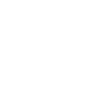

In [43]:
LineString(geo_trips[geo_trips.trip_id == '00000008-0000-1000-8ba8-5b7d6a617b60'].geometry.to_list())